<div style="background:linear-gradient(135deg,#1e1b4b 0%,#4338ca 55%,#6366f1 100%);border-radius:18px;padding:34px 30px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#c7d2fe;font-weight:700;text-transform:uppercase">Chapter 117 · Anomaly Detection</div>
  <div style="font-size:34px;font-weight:900;line-height:1.1;margin:10px 0 6px">Anomaly Detection</div>
  <div style="font-size:15px;color:#e0e7ff;max-width:740px;line-height:1.6">Finding the rare, costly points that do not fit, machine faults hidden in sensor data, with statistical (z-score, Mahalanobis), density-based (Local Outlier Factor), and isolation-based (Isolation Forest) methods, and learning the key lesson that different detectors catch different kinds of anomaly, all library-first with scikit-learn, and heavily visual.</div>
  <div style="margin-top:16px;font-size:13px;color:#c7d2fe">Statistics, Data Science and AI: A Visual Handbook · John Fisher · 2026</div>
</div>

# Anomaly Detection: finding what does not belong
Fraud, equipment faults, network intrusions, the rare, costly events hide as a tiny fraction of points that do not fit the pattern. **Anomaly detection** finds them, usually with no labels. This notebook works machine-sensor data four ways, **statistical** (z-score and Mahalanobis), **density-based** (Local Outlier Factor), and **isolation-based** (Isolation Forest), and shows the crucial lesson: different detectors catch different kinds of anomaly. Library-first with `scikit-learn`.

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import seaborn as sns   # seaborn = high-level statistical plots (heatmaps, pairplots, count/bar plots)
from matplotlib.colors import ListedColormap
EM="#4338ca"; DEEP="#3730a3"; LIGHT="#c7d2fe"; INK="#1a2138"; GRID="#e6e9f2"; RED="#ef4444"; AMBER="#d97706"; GREEN="#059669"; BLUE="#2563eb"; PUR="#9333ea"; GREY="#94a3b8"; SLATE="#475569"; ORG="#4338ca"; CYAN="#0891b2"
plt.rcParams.update({"figure.facecolor":"white","axes.facecolor":"white","figure.dpi":110,"font.size":11,
   "axes.edgecolor":GRID,"axes.grid":True,"grid.color":GRID,"axes.axisbelow":True,"axes.spines.top":False,
   "axes.spines.right":False,"axes.titlesize":12,"axes.titleweight":"bold","legend.frameon":False})
sns.set_style("whitegrid")
BASE="https://raw.githubusercontent.com/johnfisher-ai/Statistics-Data-Science-AI-Visual-Book/main/data/"

In [2]:
from sklearn.preprocessing import StandardScaler
from sklearn.covariance import EllipticEnvelope
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.metrics import recall_score, precision_score
pd.set_option('display.max_columns', 30)

<div style="background:#eef6ff;border-left:5px solid #2563eb;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#1d4ed8;letter-spacing:1px">DEMO 1 &#183; A RARE, HIDDEN MINORITY</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Sensors from 590 machines, ~5% faulty</div>
<div style="color:#4a5578;margin-top:6px">Load, look, and note two kinds of anomaly.</div>
</div>

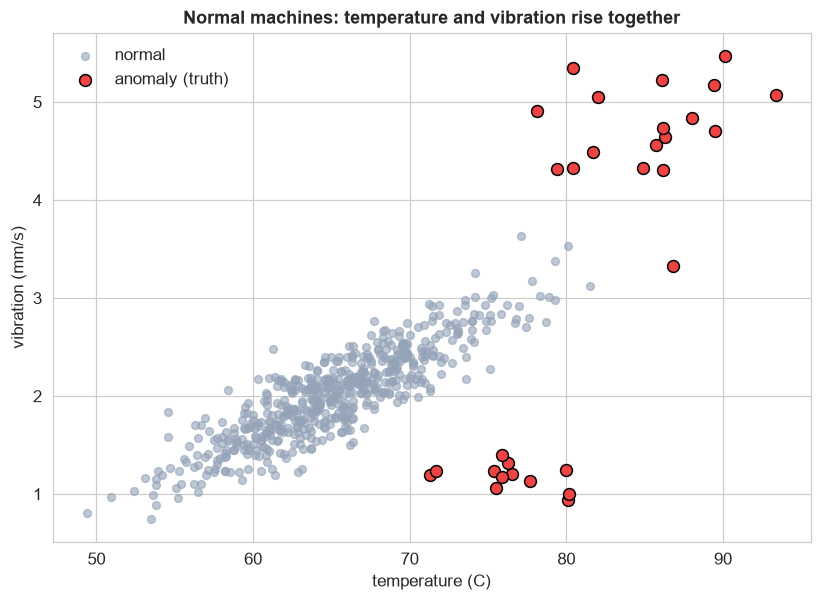

anomaly rate: 5% (30 of 590)


In [3]:
try: df = pd.read_excel('../../data/ch117_sensors.xlsx', sheet_name='Data')
except FileNotFoundError: df = pd.read_excel(BASE + 'ch117_sensors.xlsx', sheet_name='Data')
feat = ['temperature','vibration','pressure','rotation_rpm']
X = df[feat]; y = df['label']            # label is ground truth, used ONLY to score detectors
Xs = StandardScaler().fit_transform(X)
fig, ax = plt.subplots(figsize=(7.6,5.6))
ax.scatter(X['temperature'][y==0], X['vibration'][y==0], s=26, c=GREY, alpha=0.6, label='normal')
ax.scatter(X['temperature'][y==1], X['vibration'][y==1], s=60, c=RED, edgecolor='black', label='anomaly (truth)')
ax.set(xlabel='temperature (C)', ylabel='vibration (mm/s)', title='Normal machines: temperature and vibration rise together'); ax.legend()
plt.tight_layout(); plt.show()
print('anomaly rate: %.0f%% (%d of %d)' % (y.mean()*100, y.sum(), len(y)))

**Two flavors of anomaly.** In normal machines, temperature and vibration rise together (shared mechanical load), the grey cloud runs on a diagonal. The red anomalies come in two kinds. Some are **obvious**: both temperature and vibration are clearly high (top-right). Others are **subtle multivariate** anomalies: a fairly normal temperature paired with an oddly *low* vibration, so each reading alone looks fine, but the *combination* breaks the normal correlation. Catching that second kind is where anomaly detection earns its keep. Note we never train on the label, detection is **unsupervised**.

<div style="background:#eef2ff;border-left:5px solid #4338ca;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#3730a3;letter-spacing:1px">DEMO 2 &#183; STATISTICAL: THE z-SCORE</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">The 3-sigma rule, one column at a time</div>
<div style="color:#4a5578;margin-top:6px">Flag any reading more than 3 SDs from its mean.</div>
</div>

In [4]:
z = np.abs((X - X.mean()) / X.std())
flag_z = (z > 3).any(axis=1).astype(int)
obvious = (y==1) & (df['vibration']>=1.6); subtle = (y==1) & (df['vibration']<1.6)
print('z-score recall: %.2f  (obvious %d/%d, subtle %d/%d)' % (recall_score(y,flag_z), ((flag_z==1)&obvious).sum(), obvious.sum(), ((flag_z==1)&subtle).sum(), subtle.sum()))
print('precision: %.2f' % precision_score(y, flag_z))

z-score recall: 0.60  (obvious 18/18, subtle 0/12)
precision: 1.00


**Simple, and half-blind.** The classic **z-score** rule flags any value more than three standard deviations from its column mean. It nails every *obvious* anomaly with perfect precision, and catches **none** of the subtle multivariate ones. The reason is fundamental: a per-column rule sees each feature in isolation, so a 'normal temperature plus low vibration' point looks unremarkable on both axes. Univariate statistics simply cannot see anomalies that live in the *relationship between* features.

<div style="background:#eef2ff;border-left:5px solid #4338ca;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#3730a3;letter-spacing:1px">DEMO 3 &#183; MULTIVARIATE STATISTICAL: MAHALANOBIS</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Account for the correlation</div>
<div style="color:#4a5578;margin-top:6px">EllipticEnvelope fits a Gaussian and measures distance in it.</div>
</div>

EllipticEnvelope recall: 1.00  (obvious 18/18, subtle 12/12)


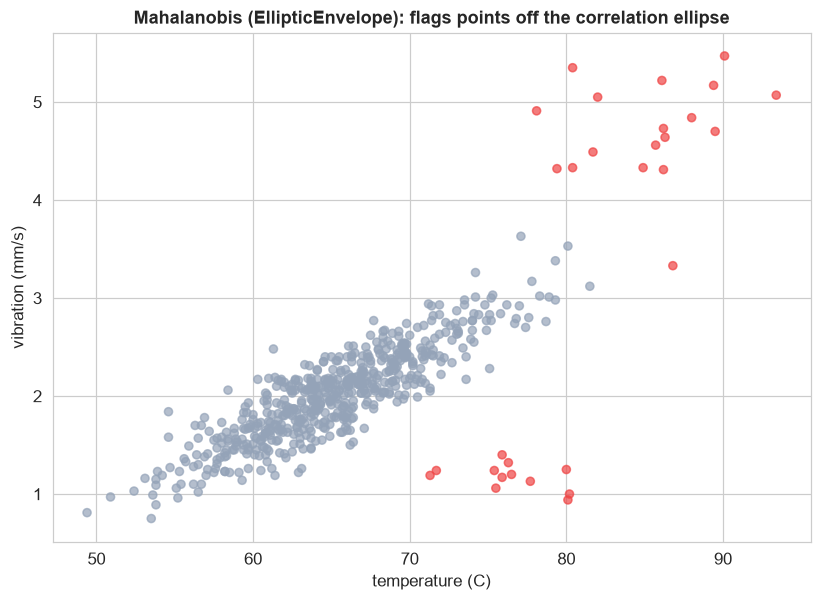

In [5]:
ee = EllipticEnvelope(contamination=float(y.mean()), random_state=0).fit(Xs)
flag_ee = (ee.predict(Xs) == -1).astype(int)
print('EllipticEnvelope recall: %.2f  (obvious %d/%d, subtle %d/%d)' % (recall_score(y,flag_ee), ((flag_ee==1)&obvious).sum(), obvious.sum(), ((flag_ee==1)&subtle).sum(), subtle.sum()))
fig, ax = plt.subplots(figsize=(7.6,5.6))
ax.scatter(X['temperature'], X['vibration'], s=28, c=np.where(flag_ee==1, RED, GREY), alpha=0.7)
ax.set(xlabel='temperature (C)', ylabel='vibration (mm/s)', title='Mahalanobis (EllipticEnvelope): flags points off the correlation ellipse')
plt.tight_layout(); plt.show()

**Distance that knows the shape.** Instead of treating features separately, **EllipticEnvelope** fits one multivariate Gaussian to the data and scores each point by its **Mahalanobis distance**, distance measured in units of the data's own covariance. Because it *knows* temperature and vibration should move together, a point off that diagonal is far in Mahalanobis terms even when it is ordinary on each axis. Here it catches **both** kinds of anomaly perfectly. The catch: it assumes the data is roughly Gaussian, a strong assumption real data often breaks.

<div style="background:#eef2ff;border-left:5px solid #4338ca;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#3730a3;letter-spacing:1px">DEMO 4 &#183; ISOLATION FOREST</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Anomalies are easy to isolate</div>
<div style="color:#4a5578;margin-top:6px">Random splits fence off outliers in just a few cuts.</div>
</div>

IsolationForest recall: 0.63  (obvious 18/18, subtle 1/12)


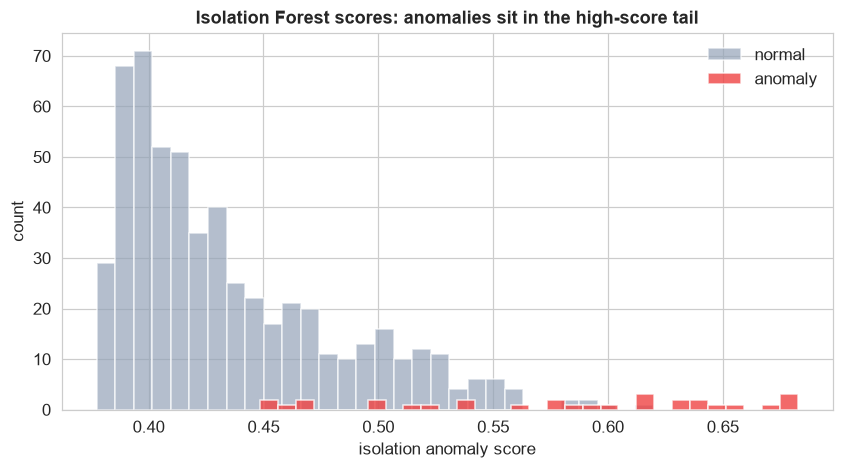

In [6]:
iso = IsolationForest(contamination=float(y.mean()), random_state=0).fit(Xs)
flag_iso = (iso.predict(Xs) == -1).astype(int)
score = -iso.score_samples(Xs)      # higher = more anomalous
print('IsolationForest recall: %.2f  (obvious %d/%d, subtle %d/%d)' % (recall_score(y,flag_iso), ((flag_iso==1)&obvious).sum(), obvious.sum(), ((flag_iso==1)&subtle).sum(), subtle.sum()))
fig, ax = plt.subplots(figsize=(7.8,4.4))
ax.hist(score[y==0], bins=30, color=GREY, alpha=0.7, label='normal')
ax.hist(score[y==1], bins=30, color=RED, alpha=0.8, label='anomaly')
ax.set(xlabel='isolation anomaly score', ylabel='count', title='Isolation Forest scores: anomalies sit in the high-score tail'); ax.legend()
plt.tight_layout(); plt.show()

**No distribution assumed.** **Isolation Forest** builds many random trees, each splitting on a random feature at a random value. Anomalies, being few and different, get **isolated in just a few splits**, so their average path length is short, which becomes a high anomaly score. It makes **no assumption** about the data's shape, scales to millions of rows and many features, and needs almost no tuning, which is why it is the practical default for large, high-dimensional problems. Here it flags the clearly-isolated points; the subtle correlation-breakers, not globally extreme on any axis, are harder for its axis-parallel cuts.

<div style="background:#eef2ff;border-left:5px solid #4338ca;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#3730a3;letter-spacing:1px">DEMO 5 &#183; DENSITY: LOCAL OUTLIER FACTOR</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Odd relative to your neighbors</div>
<div style="color:#4a5578;margin-top:6px">LOF compares a point's density to its neighbors' density.</div>
</div>

LOF recall: 0.47  (obvious 2/18, subtle 12/12)


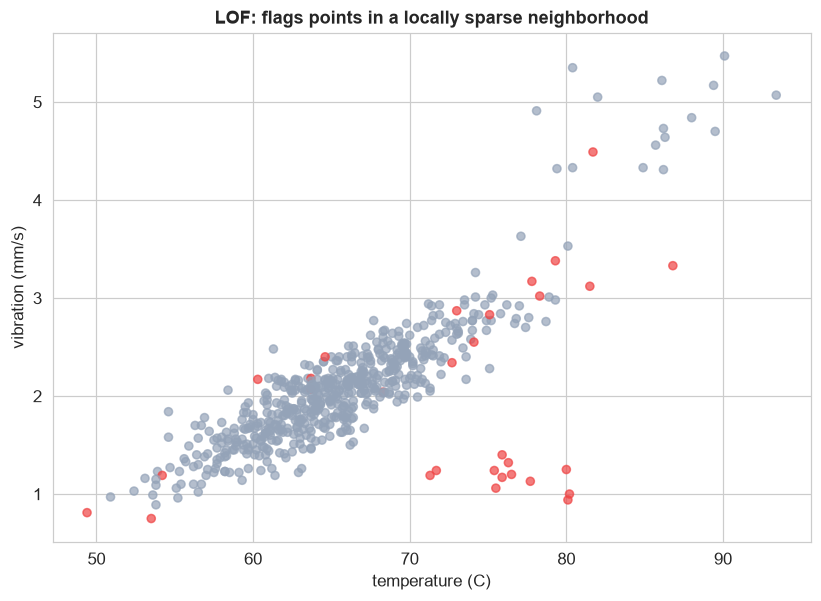

In [7]:
lof = LocalOutlierFactor(n_neighbors=20, contamination=float(y.mean()))
flag_lof = (lof.fit_predict(Xs) == -1).astype(int)
print('LOF recall: %.2f  (obvious %d/%d, subtle %d/%d)' % (recall_score(y,flag_lof), ((flag_lof==1)&obvious).sum(), obvious.sum(), ((flag_lof==1)&subtle).sum(), subtle.sum()))
fig, ax = plt.subplots(figsize=(7.6,5.6))
ax.scatter(X['temperature'], X['vibration'], s=28, c=np.where(flag_lof==1, RED, GREY), alpha=0.7)
ax.set(xlabel='temperature (C)', ylabel='vibration (mm/s)', title='LOF: flags points in a locally sparse neighborhood')
plt.tight_layout(); plt.show()

**Local, not global.** **Local Outlier Factor** asks a relative question: is this point in a much sparser region than its neighbors are? That makes it superb at the **subtle** anomalies, a point stranded off the correlation line sits in empty space relative to the dense diagonal, so LOF flags it, catching all the correlation-breakers. Interestingly it can *miss* the obvious cluster: those 18 anomalies are close enough to *each other* to look locally dense. LOF and Isolation Forest are near-opposites, and that is the point.

<div style="background:#eef2ff;border-left:5px solid #4338ca;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#3730a3;letter-spacing:1px">DEMO 6 &#183; NO FREE LUNCH</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Different detectors, different anomalies</div>
<div style="color:#4a5578;margin-top:6px">Match the method to the anomaly you fear.</div>
</div>

                method   recall  catches obvious  catches subtle
  z-score (univariate) 0.600000               18               0
Mahalanobis (elliptic) 1.000000               18              12
      Isolation Forest 0.633333               18               1
         LOF (density) 0.466667                2              12


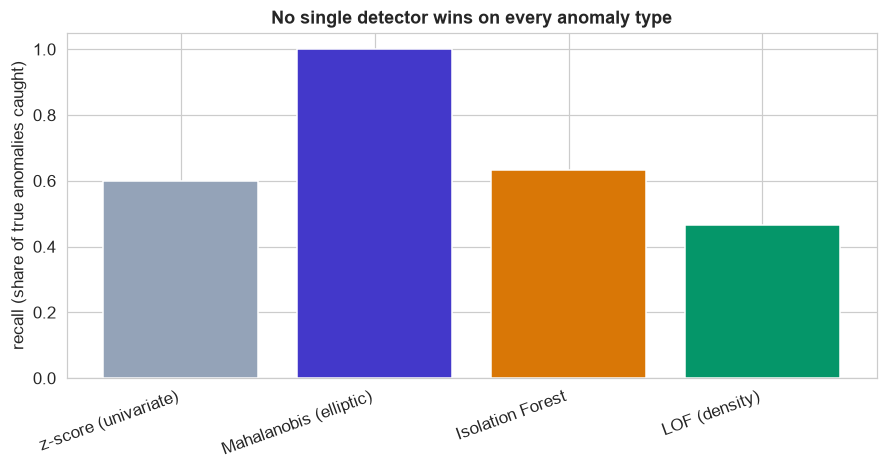

In [8]:
res = pd.DataFrame({
  'method':['z-score (univariate)','Mahalanobis (elliptic)','Isolation Forest','LOF (density)'],
  'recall':[recall_score(y,flag_z), recall_score(y,flag_ee), recall_score(y,flag_iso), recall_score(y,flag_lof)],
  'catches obvious':[((flag_z==1)&obvious).sum(), ((flag_ee==1)&obvious).sum(), ((flag_iso==1)&obvious).sum(), ((flag_lof==1)&obvious).sum()],
  'catches subtle':[((flag_z==1)&subtle).sum(), ((flag_ee==1)&subtle).sum(), ((flag_iso==1)&subtle).sum(), ((flag_lof==1)&subtle).sum()]})
print(res.to_string(index=False))
fig, ax = plt.subplots(figsize=(8.2,4.4))
ax.bar(res['method'], res['recall'], color=[GREY, EM, AMBER, GREEN])
ax.set(ylabel='recall (share of true anomalies caught)', title='No single detector wins on every anomaly type'); plt.xticks(rotation=20, ha='right')
plt.tight_layout(); plt.show()

budget rule: inspect the worst 3%  -> flag 18 of 590 units (score <= -0.588)
gap rule:  largest jump in the low tail suggests a cut near score -0.576


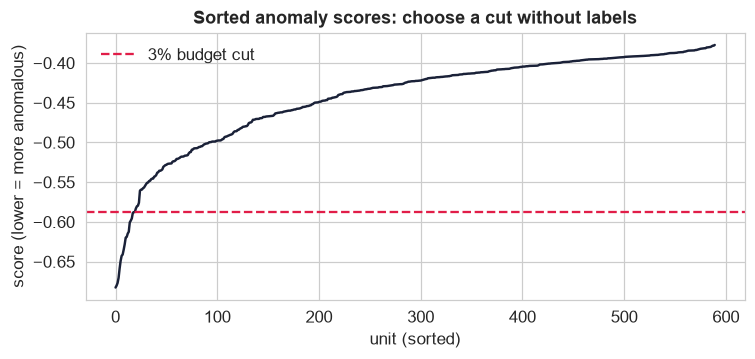

In [9]:
# In production you rarely have labels, so you cannot set contamination from y.mean().
# Score every point, then choose a cutoff from a BUDGET or a GAP in the scores, no labels needed.
iso_auto = IsolationForest(contamination="auto", random_state=0).fit(Xs)
scores = iso_auto.score_samples(Xs)          # higher = more normal, lower = more anomalous
# (a) budget rule: we can only investigate the worst 3% of units
budget = 0.03
cut_budget = np.quantile(scores, budget)
n_flag = int((scores <= cut_budget).sum())
print(f"budget rule: inspect the worst {budget:.0%}  -> flag {n_flag} of {len(scores)} units (score <= {cut_budget:.3f})")
# (b) gap rule: the biggest jump in the low tail of the sorted scores is a natural break
ss = np.sort(scores); tail = ss[:len(ss)//5]
knee = tail[np.argmax(np.diff(tail))]
print(f"gap rule:  largest jump in the low tail suggests a cut near score {knee:.3f}")
fig, ax = plt.subplots(figsize=(7,3.4))
ax.plot(np.sort(scores), color="#1a2138", lw=1.6)
ax.axhline(cut_budget, color="#e11d48", ls="--", label="3% budget cut")
ax.set(title="Sorted anomaly scores: choose a cut without labels", xlabel="unit (sorted)", ylabel="score (lower = more anomalous)"); ax.legend()
plt.tight_layout(); plt.show()

**But what if you have no labels?** Every method above was handed `contamination = y.mean()`, the true anomaly rate, which you only know because this is a teaching dataset. In production you do not. Two label-free ways to set the cutoff: a **budget** (if the team can investigate the worst 3% of units, flag the lowest-scoring 3%) or a **gap** in the sorted scores (a visible jump between the normal bulk and a straggling tail is a natural break). Score every point with `score_samples`, sort, and cut, no ground truth required. When a few confirmed cases do arrive later, use them to sanity-check the flag rate, not to set it.

**The real lesson.** There is no universally best anomaly detector, each has a blind spot. Univariate z-scores miss multivariate anomalies; Isolation Forest and Mahalanobis catch globally-isolated ones; LOF catches locally-odd ones. In practice you choose by the anomaly you most fear, or **combine** methods (flag if any detector fires) and always tune the **contamination / threshold** to trade false alarms against misses. And because anomalies are rare, evaluate with **recall and precision**, never plain accuracy, calling everything normal would score 95% here and catch nothing.

## Anomaly detection, in one view

- Anomalies are **rare and unlabeled**; detection is usually unsupervised, judge it by recall/precision, not accuracy.
- **z-score** (univariate) is simple but blind to anomalies in the *relationship* between features.
- **Mahalanobis / EllipticEnvelope** accounts for covariance, great when data is roughly Gaussian.
- **Isolation Forest** assumes nothing and scales, the go-to default for big, high-dimensional data.
- **LOF** is density-based and catches *locally* odd points; **no single method wins**, so match method to anomaly (or combine).

---
<div style="text-align:center;color:#8b94b3;font-size:12px;margin-top:10px">Statistics, Data Science and AI: A Visual Handbook · © 2026 John Fisher</div>